# Clasificació


Quan l'atribut target és categòric, és un problema de classificació, que pot ser:
* Un problema de classificació binària, si l'atribut target o objectiu és dicotòmic, és a dir,
només pren dos valors diferents.
* Un problema de classificació multiclasse, si l'atribut target o objectiu no és dicotòmic, és
dir, pren més de dos valors diferents.
Si l'atribut target és numèric, és un problema de regressió.

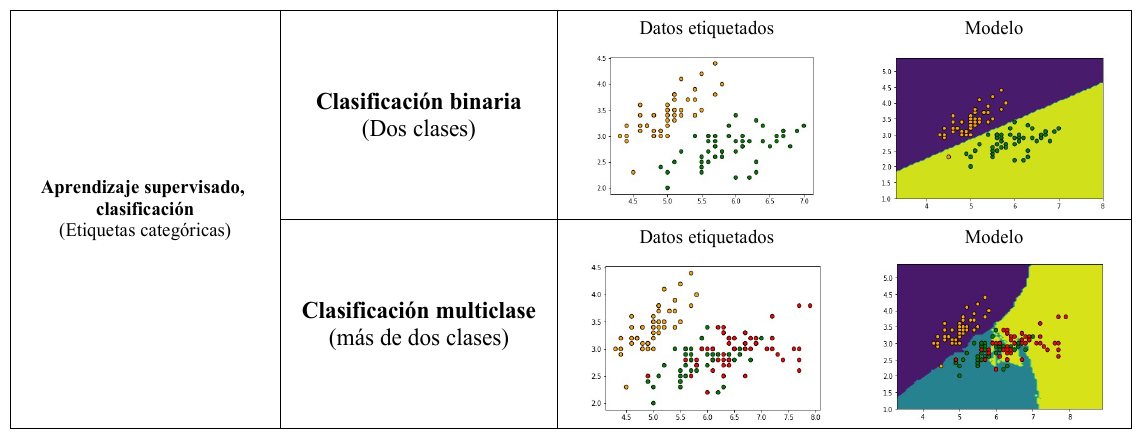

No s'han de confondre els hiperparàmetres amb els paràmetres d'un model.
* Els valors per als hiperparàmetres es fixen abans del procés d'entrenament.
* Els valors per als paràmetres s'obtenen com a resultat del procés d'entrenament. Són els
valors que minimitzen lerror.

Per a un problema de classificació, els valors de la predicció del model ŷi, i l'esperat yi, són categòrics i, per tant, només importa si són iguals o si són diferents.
L'error e(α) es calcula comparant les prediccions calculades pel model f per a les dades d'entrada
x1 , x2, ..., xN, que són ŷ1=f(x1), ŷ2=f(x2), ..., ŷN=f(xN), amb els corresponents valors reals y1, y2, ..., yN.
Una possible mitjana és l'accuracy rate o taxa d'encerts. Aquesta és la proporció de casos en què el valor predit pel model, ŷi, coincideix amb el valor real o esperat de l'etiqueta, yi. Però hi ha altres mesures es veuran a continuació.

**Característiques comunes de totes les classes de Scikit-Learn que implementen classificadors**

| Característica | Descripció |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
| **Paràmetres del constructor** | |
| `n_jobs` | (valor per defecte: `None`) Nombre de processos o fils d'execució concurrents que es poden fer servir per al càlcul. Amb el valor per defecte `None` s'usa 1 (no hi ha paral·lelisme). Amb valor `-1` s'utilitzen tots els processadors (CPU) disponibles. Aquest paràmetre és a molts classificadors de Scikit-Learn, però no a tots. |
| **Mètodes** | |
| `fit(X, y)` | Entrenar el classificador amb `X` (atributs predictors) i `y` (etiquetes). |
| `predict(X)` | Obtenir la predicció del model, un cop entrenat, per a les dades de `X`. |
| `score(X, y)` | Obtenir *accuracy score* o taxa d'encerts. |
| **Atributs** | |
| `classes_` | Etiquetes de classes. |
| `n_features_in_` | Nombre d'atributs predictors trobats i utilitzats pel mètode fit. |
| `feature_names_in_` | Noms d'atributs trobats i utilitzats per `fit`|
| `n_samples_fit_` | Número d'observacions (samples) en el dataset utilitzats per al `fit` |

### Classificador Perceptron

En aquest cas utilitzarem el classificador més simple. Es tracta del `Perceptron`, un classificador lineal per a classificació `binaria`. L'entrenament busca una recta en un planol que separe de la millor manera les dos classes. Si un element està mesclar en l'altra classe mai serà classificat correctament, com es veu a la gràfica.

Aquest classificador sols és útil si les dades són linealment separables.

Tasa de aciertos: 0.99


Text(0, 0.5, 'sepal_width')

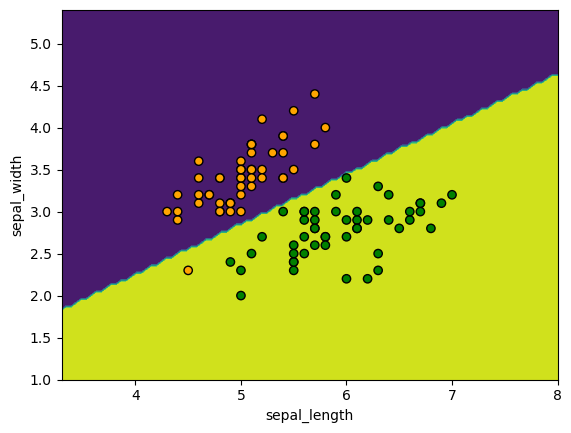

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score
from sklearn.inspection import DecisionBoundaryDisplay
import numpy as np
df = pd.read_csv(
"https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data",
names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
)
# Dos clases (clasificación binaria)
df = df[df['class'].isin(['Iris-setosa', 'Iris-versicolor'])]
# x, y
x = df[['sepal_length', 'sepal_width']]
y = df['class']
# Creación de un clasificador lineal (perceptron)
clf = Perceptron()
# Entrenamiento del clasificador
clf.fit(x, y)
# Predicción para datos de entrenamiento
y_pred = clf.predict(x)
# Tasa de aciertos
acc_score = accuracy_score(y, y_pred)
print('Tasa de aciertos: {acc_sc}'.format(acc_sc=acc_score))

# Mostrar fronteras de decisión del clasificador
DecisionBoundaryDisplay.from_estimator(clf, x, response_method="predict")
# Mostrar datos de entrenamiento
colores = {'Iris-setosa':'orange', 'Iris-versicolor':'green' }
plt.scatter(x['sepal_length'], x['sepal_width'], c=y.map(colores), edgecolor='k')
plt.xlabel("sepal_length")
plt.ylabel("sepal_width")


Aquesta és la manera directa de fer i representar el `perceptron`, anem a interpretar el resultat. En primer lloc traurem els coeficients  i el intercept que ha tret l'entrenament. Amb això imprimim l'ecuació a aplicar. 

L'ecuació 

$$y = f(w_1x_1 + w_2x_2 + \dots + w_nx_n + b)$$ 

on els $w$ són els coeficients i els x són sepal_length i sepal_width. Si el resultat de la funció ($y$) és major que 0 és la classe 1 (Iris-versicolor) i si és menor que 0 la classe 0 (Iris-setosa)

In [26]:
# Obtenim els valors
coefs = clf.coef_[0] # Accedim a l'array dins de l'array
intercept = clf.intercept_[0]
feature_names = clf.feature_names_in_

# Construïm la part de l'equació
equacio_parts = []
for i in range(len(coefs)):
    # Formategem cada terme: w*x
    terme = f"({coefs[i]:.2f} * {feature_names[i]})"
    equacio_parts.append(terme)

# Unim tot amb signes '+'
equacio_final = " + ".join(equacio_parts) + f" + ({intercept:.2f})"

print(f"Ecuació resultant: y = {equacio_final}")
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

sample = df_shuffled[:1]
print("Exemple:",sample)
ecuacio_exemple = f"{coefs[0]:.2f} * {sample['sepal_length'].values[0]} + {coefs[1]:.2f} * {sample['sepal_width'].values[0]} + ({intercept:.2f})"
resultat_ecuacio =  coefs[0]*sample['sepal_length'].values[0]+ coefs[1]*sample['sepal_width'].values[0]+intercept
print("Ecuació per a l'exemple:",ecuacio_exemple, '=', resultat_ecuacio)

for index, classe in enumerate(clf.classes_):
    print(f"Classe {classe} ha estat assignada a l'índex: {index}")



Ecuació resultant: y = (22.00 * sepal_length) + (-36.90 * sepal_width) + (-5.00)
Exemple:    sepal_length  sepal_width  petal_length  petal_width            class
0           6.0          2.7           5.1          1.6  Iris-versicolor
Ecuació per a l'exemple: 22.00 * 6.0 + -36.90 * 2.7 + (-5.00) = 27.369999999999933
Classe Iris-setosa ha estat assignada a l'índex: 0
Classe Iris-versicolor ha estat assignada a l'índex: 1


En la gràfica següent es representen els resultats de l'ecuació per als registres del dataset. Els resultats són positius i negatius, per tant el 0 es queda al mij i fa de separació quasi perfecta entre les classes reals representades en colors.
El punt de l'exemple es representa en roig. 

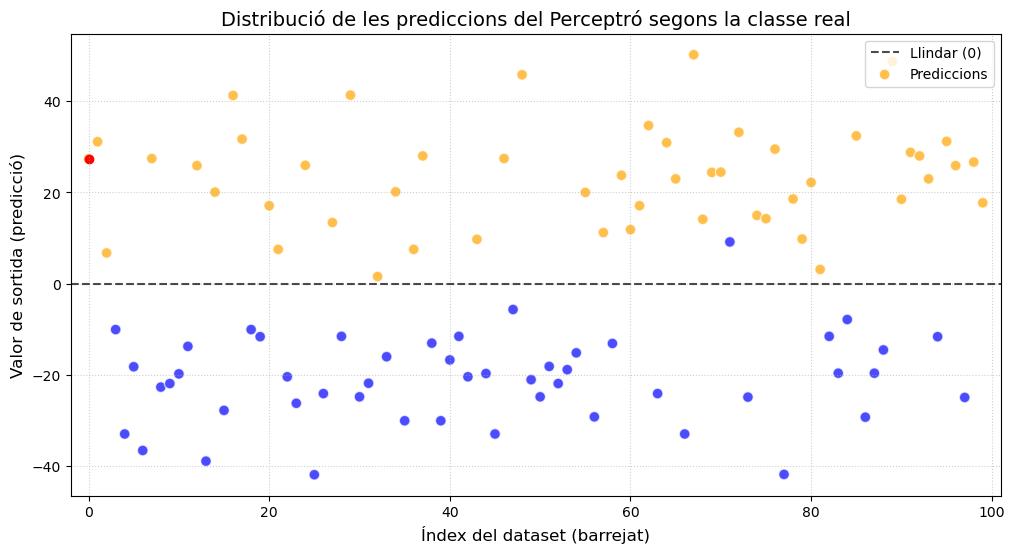

In [28]:
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Configuració d'estil
plt.figure(figsize=(12, 6))

# Línia de referència (llindar de decisió en 0)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Llindar (0)')

# Scatter plot
plt.scatter(
    df_shuffled.index, 
    y_pred, 
    s=60, 
    alpha=0.7, 
    edgecolors='w',
    c=df_shuffled['class'].map({'Iris-setosa': 'blue', 'Iris-versicolor': 'orange'}),
    label='Prediccions'
)
plt.scatter(0,resultat_ecuacio,color="red")

# Millores visuals
plt.title('Distribució de les prediccions del Perceptró segons la classe real', fontsize=14)
plt.xlabel('Índex del dataset (barrejat)', fontsize=12)
plt.ylabel('Valor de sortida (predicció)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

# Afegim una mica d'espai als marges
plt.margins(x=0.02)

plt.show()

La següent gràfica representa les dades d'una altra manera, la mateixa que `DecisionBoundaryDisplay`. 

Text(0, 0.5, 'sepal_width')

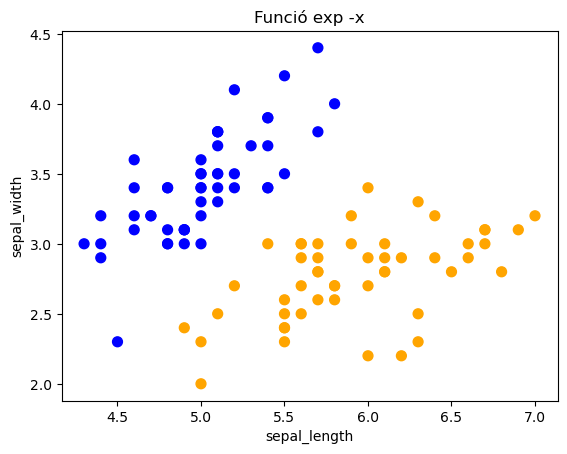

In [29]:
plt.scatter(df['sepal_length'], df['sepal_width'], s=50, label="Dades", c=df['class'].map({'Iris-setosa':'blue','Iris-versicolor':'orange'}))

plt.title('Funció exp -x')
plt.xlabel('sepal_length')
plt.ylabel('sepal_width')

Per afegir la **línia de decisió** del perceptró en un gràfic bidimensional (on els eixos són les característiques), hem de resoldre l'equació per a $y=0$.

Com que el perceptró és $w_1x_1 + w_2x_2 + b = 0$, aïllem $x_2$ (en aquest cas `sepal_width`):

$$x_2 = \frac{-(w_1 \cdot x_1 + b)}{w_2}$$

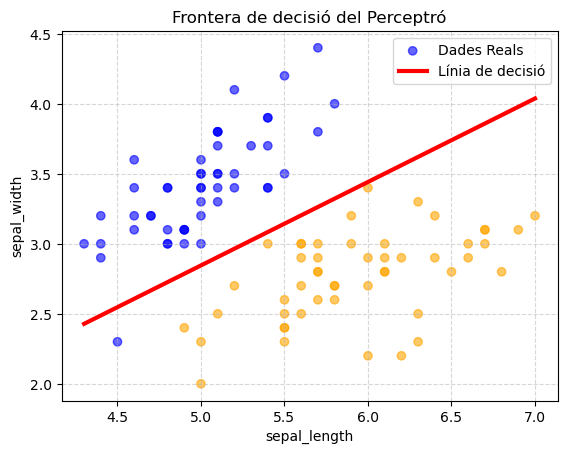

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Dibuixem les dades originals (scatter)
plt.scatter(df['sepal_length'], df['sepal_width'], 
            c=df['class'].map({'Iris-setosa':'blue', 'Iris-versicolor':'orange'}),
            label="Dades Reals", alpha=0.6)

# 2. Calculem la línia de decisió
# Definim un rang per a l'eix X (sepal_length)
x_vals = np.linspace(df['sepal_length'].min(), df['sepal_length'].max(), 100)

# Apliquem la fórmula per obtenir els punts de la línia (sepal_width)
# w1*x1 + w2*x2 + b = 0  => x2 = -(w1*x1 + b) / w2
y_vals = -(coefs[0] * x_vals + intercept) / coefs[1]

# Dibuixem la línia
plt.plot(x_vals, y_vals, color="red", linewidth=3, label="Línia de decisió")

# 3. Millores visuals
plt.title('Frontera de decisió del Perceptró')
plt.xlabel('sepal_length')
plt.ylabel('sepal_width')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Classificador KNeighborsClassifier

El modelo de clasificación es k-NN. Es un modelo muy sencillo. Dado que hay dos atributos predictores,
cada observación se representa mediante un punto en un espacio bidimensional. Para clasificar cada observa -
ción, se consideran las k observaciones más cercanas. k es un hiperparámetro del modelo, cuyo valor hay
que establecer antes del proceso de entrenamiento. La observación se asigna a la clase más frecuente entre
las k observaciones más cercanas.

Tasa de aciertos: 0.84


Text(0, 0.5, 'sepal_width')

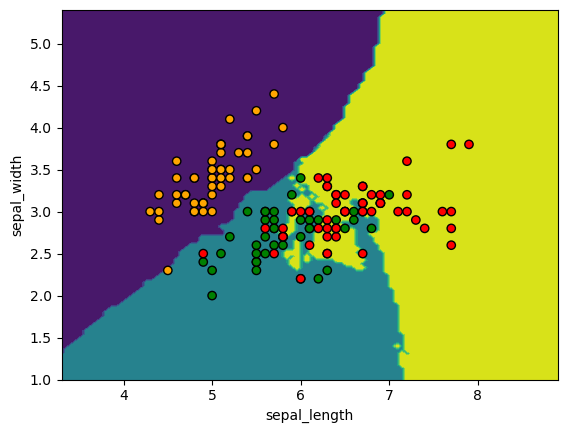

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import DecisionBoundaryDisplay
df = pd.read_csv(
"https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data" ,
names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
)
# x, y
x = df[['sepal_length', 'sepal_width']]
y = df['class']
# Creación de un clasificador k-NN (k vecinos más cercanos)
clf = KNeighborsClassifier(n_neighbors=5)
# Entrenamiento del clasificador
clf.fit(x, y)
# Predicción para datos de entrenamiento
y_pred = clf.predict(x)
# Tasa de aciertos
acc_score = accuracy_score(y, y_pred)
print('Tasa de aciertos: {acc_sc}'.format(acc_sc=acc_score))
## Mostrar fronteras de decisión del clasificador
DecisionBoundaryDisplay.from_estimator(clf, x, response_method="predict")
# Mostrar datos de entrenamiento
colores = {'Iris-setosa':'orange', 'Iris-versicolor':'green', 'Iris-virginica':'red' }
plt.scatter(x['sepal_length'], x['sepal_width'], c=y.map(colores), edgecolor='k')
plt.xlabel("sepal_length")
plt.ylabel("sepal_width")

Se puede comprobar que la tasa de aciertos es del 84%. Hay dos clases (Iris-versicolor e Iris-Virginica)
cuyas observaciones están bastante entremezcladas entre sí. Pero el clasificador permite una clasificación
bastante flexible, al asignar cada observación a la clase más frecuente entre las 5 observaciones más próxi -
mas.

### Hiperparàmetres i sobreajust

Muchos modelos tienen hiperparámetros, cuyos valores hay que fijar antes de empezar el proceso de
aprendizaje. Se muestra un ejemplo con un modelo de regresión polinómico. El valor de la variable target,
y, se calcula con un polinomio de una variable predictora x. El grado del polinomio es un hiperparámetro del
modelo. Con valor 1 para este hiperparámetro, los únicos modelos que se pueden obtener como resultado del
proceso de entrenamiento son modelos lineales de la forma y = α0 + α1x . Si se fija un valor de 2, se pueden
obtener modelos en que el valor de y se calcula con un polinomio de segundo grado, y = α0 + α1x + α2x2.

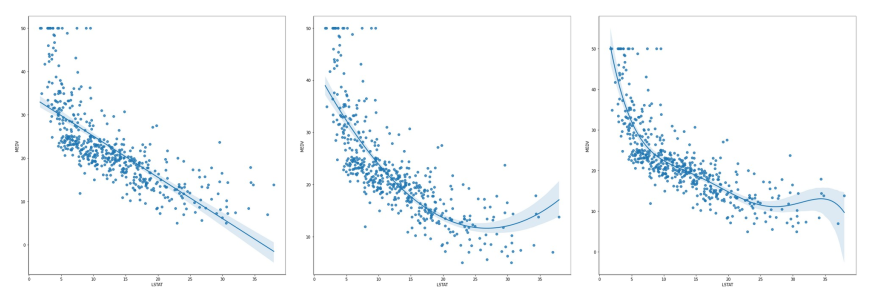

Una adecuada selección de los hiperparámetros es determinante para obtener un modelo apropiado para
un dataset. Los valores fijados para los hiperparámetros restringen el conjunto de posibles modelos que se
pueden obtener como resultado del proceso de aprendizaje y, por tanto, la capacidad de obtener un modelo
que se ajuste a un dataset dado.
El primero de los tres modelos modelos anteriores adolece de un ajuste insuficiente a los datos (underfi-
tting). Porque un modelo de regresión lineal es demasiado sencillo para este dataset. El último es el que me-
jor se ajusta a los datos de entrenamiento, pero seguramente demasiado. Hay pocos datos a la derecha, para
valores altos de la variable predictora, pero tienen mucha influencia en la forma de la curva. Hay sobreajuste
u overfitting, y este modelo no dará tan buenas predicciones para datos nuevos como el segundo. Es necesa-
rio, por tanto, un compromiso entre un buen ajuste a los datos de entrenamiento y una suficiente generalidad
para proporcionar buenas predicciones para nuevos datos que se puedan presentar más adelante.
También para modelos de clasificación se plantea la elección de valores para los hiperparámetros para
conseguir un buen ajuste a los datos de entrenamiento, a la vez que se evita el sobreajuste. En el ejemplo an -
terior de clasificador k-NN, se ha elegido un valor k=5, siendo k el número de observaciones más cercanas
que se tienen en cuenta para clasificar una observación. Pero se puede probar con otros valores.

La tasa de aciertos mejora ligeramente con k=3, y los cambios en las fronteras de decisión son pequeños.
Con k=1, la tasa de aciertos sube notablemente. Pero aparecen cambios notables en las fronteras de decisión
que parecen cuestionables. A saber: a la izquierda abajo aparece una región aislada alrededor de una obser -
vación para Iris-virginica, alejada de cualquier otra para la misma especie. Y en la parte de abajo por el cen -
tro aparece una nueva región muy amplia para la clase Iris-virginica, debida a la existencia de una única ob-
servación para esta clase. Estos parecen claros ejemplos de sobreajuste (overfitting). Se podría argumentar
que en la región de abajo se puede esperar que no hayan datos, por lo que este cambio no irá en detrimento
de la respuesta del modelo para datos reales. Pero también que el propio dato por el que existe esta región no
es representativo, porque está en un lugar en el que no hay más datos de esa clase. En otras palabras, que es
un outlier, y que se obtendría un modelo mejor si se elimina del dataset antes de inducir el modelo a partir
de él. Se puede decir esto mismo, y con más razón, del dato más a la izquierda en torno al cual aparece una
isla. Yse puede argumentar, desde luego, que con un dataset de solo 150 observaciones no se puede dar una
respuesta a estas cuestiones, y que harían falta muchos más datos.
Con diferentes valores para los hiperparámetros se obtienen distintos clasificadores, cada uno con una
tasa de aciertos diferente. Pero una mayor tasa de aciertos no implica necesariamente un mejor clasificador.
Porque el objetivo último de un clasificador no es la mejor clasificación posible para los datos de entrena-
miento, que de todas formas ya están clasificados, sino para nuevos y diferentes datos.
En problemas sencillos como estos, con pocos datos y de baja dimensionalidad, que se pueden represen -
tar en un gráfico bidimensional, y con modelos sencillos como estos, con un único hiperparámetro, se puede
sencillamente probar con varios valores, obtener para cada uno el valor de una métrica, y obtener y valorar
gráficas del modelo junto con los datos, para seleccionar un valor de los hiperparámetros que permitan obte-
ner un modelo lo bastante ajustado a los datos de entrenamiento, pero no sobreajustado.
Cuando se tiene un dataset con miles o millones de observaciones, con una dimensionalidad elevada (de-
cenas o incluso centenares de atributos, tanto categóricos como numéricos), y se intenta ajustar un modelo
con muchos hiperparámetros, la cosa se complica bastante, y el planteamiento anterior no es viable. Hace
falta un planteamiento más sistemático y analítico, que permita generar automáticamente modelos para dife -
rentes combinaciones de valores de los hiperparámetros, y seleccionar el mejor en base a medidas cuantitati -
vas, para conseguir un buen ajuste a los datos de entrenamiento, evitando a la vez el sobreajuste. De esto se
ocupa la siguiente sección.

### Classificador k-nearest neighbors vote amb optimitzador GridSearchCV

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
df = pd.read_csv(
"https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data",
names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
)
# Llevar la classe target en la x i fer que siga la y
x = df.drop(['class'], axis=1)
y = df['class']
# Normalitzar perquè l'algorisme es basa en distància.
# Observem que es fan operacions vectorials en Numpy
x = (x-np.min(x)) / (np.max(x)-np.min(x))
# Conjunt de valors per provar els hiperparàmetres
param_dist = {
'n_neighbors': np.arange(1, 20), # k (Número de veins)
'weights': ['uniform', 'distance'], # Ponderació de pesos
"p": [1, 2, 10, 20]
}
 # p per a distància de Minkowski
grid_clf = GridSearchCV(
    estimator = KNeighborsClassifier(metric = 'minkowski'),
    param_grid = param_dist,
    cv = 5)
grid_clf.fit(x, y)
clf = grid_clf.best_estimator_
print(grid_clf.best_params_)
print(grid_clf.best_score_)

{'n_neighbors': np.int64(6), 'p': 10, 'weights': 'uniform'}
0.9866666666666667


Según el clasificador, puede ser necesario o conveniente utilizar o no determinados atributos como atri-
butos predictores. Algunos solo funcionan con atributos predictores numéricos. Alguno hay que solo funcio -
na con atributos categóricos. Según el clasificador, puede ser conveniente realizar determinados preprocesa -
mientos sobre los atributos. Ya se ha visto, por ejemplo, que para k-NN es conveniente normalizar los valo-
res de los atributos predictores, que deben ser todos numéricos, para que tomen valores entre 0 y 1.
El ajuste del modelo, o entrenamiento, se hace con el método fit(), al que se le pasan valores para dos
parámetros X (atributos predictores) e y (etiquetas o valores para el atributo target).
Después se realiza la validación. Para ello, se utiliza el método predict() para obtener la predicción
del clasificador para los datos de un conjunto de validación. Estas predicciones se comparan con los valores
correctos para las etiquetas, para obtener una métrica de la calidad de los resultados.
Por último, una vez realizado el ajuste del modelo, existen atributos que proporcionan información rele-
vante acerca del modelo o de los datos proporcionados para el entrenamiento. En la tabla anterior se descri -
ben algunos que existen en general para todas las clases que implementan un clasificador. Pero cada clasifi-
cador tendrá sus propios atributos adicionales, en los que se puede obtener información adicional específica
del clasificador.
Otras características comunes a gran parte de los clasificadores de Scikit-Learn son las siguientes. Nor-
malmente no será interesante asignar para ellas un valor diferente al valor por defecto.

Cuadro 3.2: Características presentes en gran parte de las clases de Scikit-Learn que implementan clasificadores
Parámetros
del
constructor
Métodos
class_weight
sample_weight
random_state
predict_proba(X)
Pesos para las observaciones de cada una de las clases. Los valores típicos son los siguien-
tes.
•
•
•
None. El valor por defecto. El peso es igual para todas las observaciones.
Un dict o diccionario, que contiene el peso para cada una de las clases.
'balanced'. Se asigna a cada observación un peso inversamente proporcional a
la frecuencia relativa en el dataset de entrenamiento de la clase a la que pertenece.
De esta forma, las observaciones pertenecientes a clases menos frecuentes tienen un
peso mayor.
Cada clasificador utilizará de manera distinta estos pesos. Pero con frecuencia, cuando se
tiene un dataset desequilibrado, será recomendable el valor 'balanced'.
Pesos para observaciones particulares. Se pueden usar conjuntamente pesos diferentes para
clases diferentes (class_weight) y pesos diferentes para observaciones diferentes
(sample_weight).
Semilla para la generación de números pseudoaleatorios. Muchos algoritmos de clasifica-
ción utilizan números (pseudo)aleatorios. Para obtener los mismos resultados en sucesivas
ejecuciones del proceso de entrenamiento, debe utilizarse el mismo valor para este pará -
metro.
Obtener las probabilidades de que cada una de las observaciones de X pertenezcan a cada
una de las clases.

## Cuadro 3.2: Características presentes en gran parte de las clases de Scikit-Learn que implementan clasificadores

| Característica        | Descripción                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     |
|-----------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Parámetros del constructor** |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 |
| `class_weight`        | Pesos para las observaciones de cada una de las clases. Los valores típicos son los siguientes:
:white_small_square: **`None`**: El valor por defecto. El peso es igual para todas las observaciones.
:white_small_square: Un `dict` o diccionario, que contiene el peso para cada una de las clases.
:white_small_square: `'balanced'`: Se asigna a cada observación un peso inversamente proporcional a la frecuencia relativa en el dataset de entrenamiento de la clase a la que pertenece. De esta forma, las observaciones pertenecientes a clases menos frecuentes tienen un peso mayor.
Cada clasificador utilizará de manera distinta estos pesos. Pero con frecuencia, cuando se tiene un dataset desequilibrado, será recomendable el valor `'balanced'`. |
| `sample_weight`       | Pesos para observaciones particulares. Se pueden usar conjuntamente pesos diferentes para clases diferentes (`class_weight`) y pesos diferentes para observaciones diferentes (`sample_weight`).                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               |
| `random_state`        | Semilla para la generación de números pseudoaleatorios. Muchos algoritmos de clasificación utilizan números (pseudo)aleatorios. Para obtener los mismos resultados en sucesivas ejecuciones del proceso de entrenamiento, debe utilizarse el mismo valor para este parámetro.                                                                                                                                                                                                                                                                                                                                                                                                                                                        |
| **Métodos**           |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 |
| `predict_proba(X)`    | Obtener las probabilidades de que cada una de las observaciones de `X` pertenezcan a cada una de las clases.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   |

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()

NameError: name 'y_pred' is not defined